# Notebook 01 — Data Preprocessing (Stage 1)
Loads NYC DSNY monthly tonnage data + community district boundaries, cleans and joins them.

**Outputs:** `tonnage_clean.parquet`, `districts.geojson`, `waste_map.png`

In [1]:
# Setup: imports and project paths. All paths are absolute so this notebook
# runs correctly regardless of where Jupyter's working directory happens to be.
from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

%matplotlib inline

PROJECT = Path(r"C:\Users\pande\OneDrive\Documents\Waste management grid")
RAW = PROJECT / "data" / "raw"
PROCESSED = PROJECT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

print("Raw folder exists:", RAW.exists())
print("CSV files found:", list(RAW.glob("*.csv")))

Raw folder exists: True
CSV files found: [WindowsPath('C:/Users/pande/OneDrive/Documents/Waste management grid/data/raw/Community_Districts_20260729.csv'), WindowsPath('C:/Users/pande/OneDrive/Documents/Waste management grid/data/raw/DSNY_Districts_20260729.csv'), WindowsPath('C:/Users/pande/OneDrive/Documents/Waste management grid/data/raw/DSNY_Monthly_Tonnage_Data_20260729.csv')]


In [2]:
# Load the raw DSNY monthly tonnage CSV (waste collected per borough/community district per month).
tonnage = pd.read_csv(RAW / "DSNY_Monthly_Tonnage_Data_20260729.csv")
print("Shape:", tonnage.shape)
tonnage.head()

Shape: (25119, 12)


,MONTH,BOROUGH,COMMUNITYDISTRICT,REFUSETONSCOLLECTED,PAPERTONSCOLLECTED,MGPTONSCOLLECTED,RESORGANICSTONS,SCHOOLORGANICTONS,LEAVESORGANICTONS,XMASTREETONS,OTHERORGANICSTONS,BOROUGH_ID
0,2026 / 06,Bronx,1,3713.8,259.1,149.2,24.1,56.8,NaN,NaN,NaN,2
1,2026 / 06,Bronx,2,8137.7,250.3,202.3,16.3,76.8,NaN,NaN,NaN,2
2,2026 / 06,Bronx,3,2402.2,145.9,150.0,23.9,NaN,NaN,NaN,NaN,2
3,2026 / 06,Bronx,4,4353.5,279.9,304.8,29.8,50.6,NaN,NaN,NaN,2
4,2026 / 06,Bronx,5,3725.0,277.8,319.1,25.1,51.7,NaN,NaN,NaN,2


In [3]:
# Clean and engineer the tonnage table:
#  - parse the MONTH string into a real date
#  - build the BoroCd join key used to match tonnage records to district boundaries
#  - force waste columns to numeric (some contain non-numeric junk values) and sum into total_tons
tonnage["date"] = pd.to_datetime(
    tonnage["MONTH"].str.replace(" / ", "-") + "-01"
)

tonnage["BoroCd"] = (
    tonnage["BOROUGH_ID"].astype(int) * 100
    + tonnage["COMMUNITYDISTRICT"].astype(int)
)

waste_cols = [
    "REFUSETONSCOLLECTED", "PAPERTONSCOLLECTED", "MGPTONSCOLLECTED",
    "RESORGANICSTONS", "SCHOOLORGANICTONS", "LEAVESORGANICTONS",
    "XMASTREETONS", "OTHERORGANICSTONS",
]
tonnage[waste_cols] = tonnage[waste_cols].apply(pd.to_numeric, errors="coerce")
tonnage[waste_cols] = tonnage[waste_cols].fillna(0)
tonnage["total_tons"] = tonnage[waste_cols].sum(axis=1)

print("Date range:", tonnage["date"].min(), "to", tonnage["date"].max())
print("Unique districts:", tonnage["BoroCd"].nunique())
tonnage[["date", "BOROUGH", "COMMUNITYDISTRICT", "BoroCd", "total_tons"]].head()

Date range: 1990-01-01 00:00:00 to 2026-06-01 00:00:00
Unique districts: 59


,date,BOROUGH,COMMUNITYDISTRICT,BoroCd,total_tons
0,2026-06-01,Bronx,1,201,4203.0
1,2026-06-01,Bronx,2,202,8683.4
2,2026-06-01,Bronx,3,203,2722.0
3,2026-06-01,Bronx,4,204,5018.6
4,2026-06-01,Bronx,5,205,4398.7


In [4]:
# Load community district boundary shapes and parse the WKT geometry column into real polygons.
districts = pd.read_csv(RAW / "Community_Districts_20260729.csv")
districts["BoroCd"] = districts["BoroCd"].astype(int)
districts["geometry"] = districts["the_geom"].apply(wkt.loads)

gdf = gpd.GeoDataFrame(districts, geometry="geometry", crs="EPSG:4326")
print("District polygons:", len(gdf))
gdf[["BoroCd", "Shape_Area"]].head()

District polygons: 71


,BoroCd,Shape_Area
0,410,"172,077,374.82"
1,483,"191,997,998.939"
2,226,"50,565,041.6084"
3,313,"88,264,690.3446"
4,105,"43,790,040.2362"


In [5]:
# Validate the join key: confirm which BoroCd codes exist in tonnage vs. district shapes.
# Note (for report): 71 districts exist geographically, but only 59 have tonnage records —
# the missing 12 are non-standard-numbered, large-area codes consistent with parks/airports/
# non-residential zones with no regular DSNY collection. This is a documented data limitation,
# not a pipeline bug.
tonnage_ids = set(tonnage["BoroCd"].unique())
shape_ids = set(gdf["BoroCd"].unique())

print("In tonnage but NOT in shapes:", sorted(tonnage_ids - shape_ids))
print("In shapes but NOT in tonnage:", sorted(shape_ids - tonnage_ids))
print("Matched districts:", len(tonnage_ids & shape_ids))

In tonnage but NOT in shapes: []
In shapes but NOT in tonnage: [np.int64(164), np.int64(226), np.int64(227), np.int64(228), np.int64(355), np.int64(356), np.int64(480), np.int64(481), np.int64(482), np.int64(483), np.int64(484), np.int64(595)]
Matched districts: 59


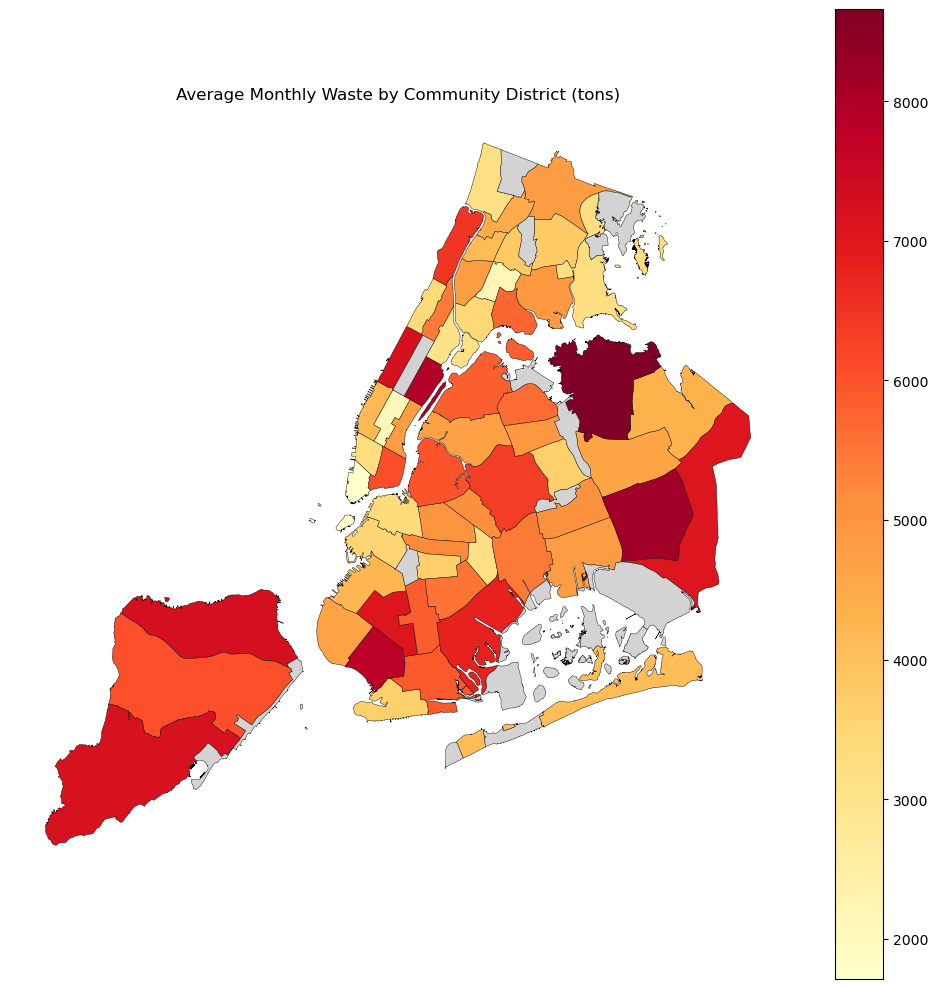

In [6]:
# Sanity-check visualization: average monthly waste per district, plotted on the real city map.
# Confirms the join worked correctly before saving anything to disk.
avg_waste = tonnage.groupby("BoroCd")["total_tons"].mean().reset_index()
mapped = gdf.merge(avg_waste, on="BoroCd", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
mapped.plot(column="total_tons", legend=True, cmap="YlOrRd",
            edgecolor="black", linewidth=0.3, ax=ax,
            missing_kwds={"color": "lightgrey"})
ax.set_title("Average Monthly Waste by Community District (tons)")
ax.axis("off")
plt.tight_layout()
plt.savefig(PROCESSED / "waste_map.png", dpi=150)
plt.show()

In [7]:
# Save final Stage 1 outputs. Re-running this notebook always overwrites these same filenames,
# so no stale/duplicate files accumulate across runs.
tonnage.to_parquet(PROCESSED / "tonnage_clean.parquet", index=False)
gdf.to_file(PROCESSED / "districts.geojson", driver="GeoJSON")

print("Saved:")
print(" -", PROCESSED / "tonnage_clean.parquet")
print(" -", PROCESSED / "districts.geojson")
print(" -", PROCESSED / "waste_map.png")
print("\nNotebook 01 complete.", tonnage.shape[0], "tonnage rows,", gdf.shape[0], "district shapes.")

C:\Users\pande\anaconda3\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Saved:
 - C:\Users\pande\OneDrive\Documents\Waste management grid\data\processed\tonnage_clean.parquet
 - C:\Users\pande\OneDrive\Documents\Waste management grid\data\processed\districts.geojson
 - C:\Users\pande\OneDrive\Documents\Waste management grid\data\processed\waste_map.png

Notebook 01 complete. 25119 tonnage rows, 71 district shapes.
